# Feature Importance Analysis

Evaluates the discriminative power of geometric features derived from optic disc and cup masks in the ORIGA dataset.
Results are pre-computed by [`feature_importance.py`](feature_importance.py) - run that script before opening this notebook.

While several markers are statistically significant, their substantial overlap limits single-timepoint glaucoma diagnosis. These features are most valuable as consistent, automated surrogates for longitudinal monitoring.

This notebook:
- presents per-feature ROC-AUC and statistical test results
- compares multivariate models (L1 Logistic Regression vs Random Forest)
- summarises feature importance from both models

## 1. Setup & data paths

In [14]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RESULTS_DIR = Path("results")

with open(RESULTS_DIR / "feature_results.json") as f:
    r = json.load(f)

## 2. Feature engineering from ORIGA masks

## 3. Univariate evaluation (ROC–AUC + statistical tests)

,auc,mw_p,ks_p,t_p,f
metric,,,,,
vertical_cdr,0.8277,0.0000,0.0000,0.0000,0.8277
area_cdr,0.8126,0.0000,0.0000,0.0000,0.8126
rdr,0.7873,0.0000,0.0000,0.0000,0.7873
horizontal_cdr,0.7549,0.0000,0.0000,0.0000,0.7549
isnt_violations,0.5234,0.2325,0.6240,0.3356,0.5234
cup_eccentricity,0.4948,0.8412,0.8626,0.4178,0.4948
cup_offset,0.4470,0.0406,0.1090,0.0921,0.4470


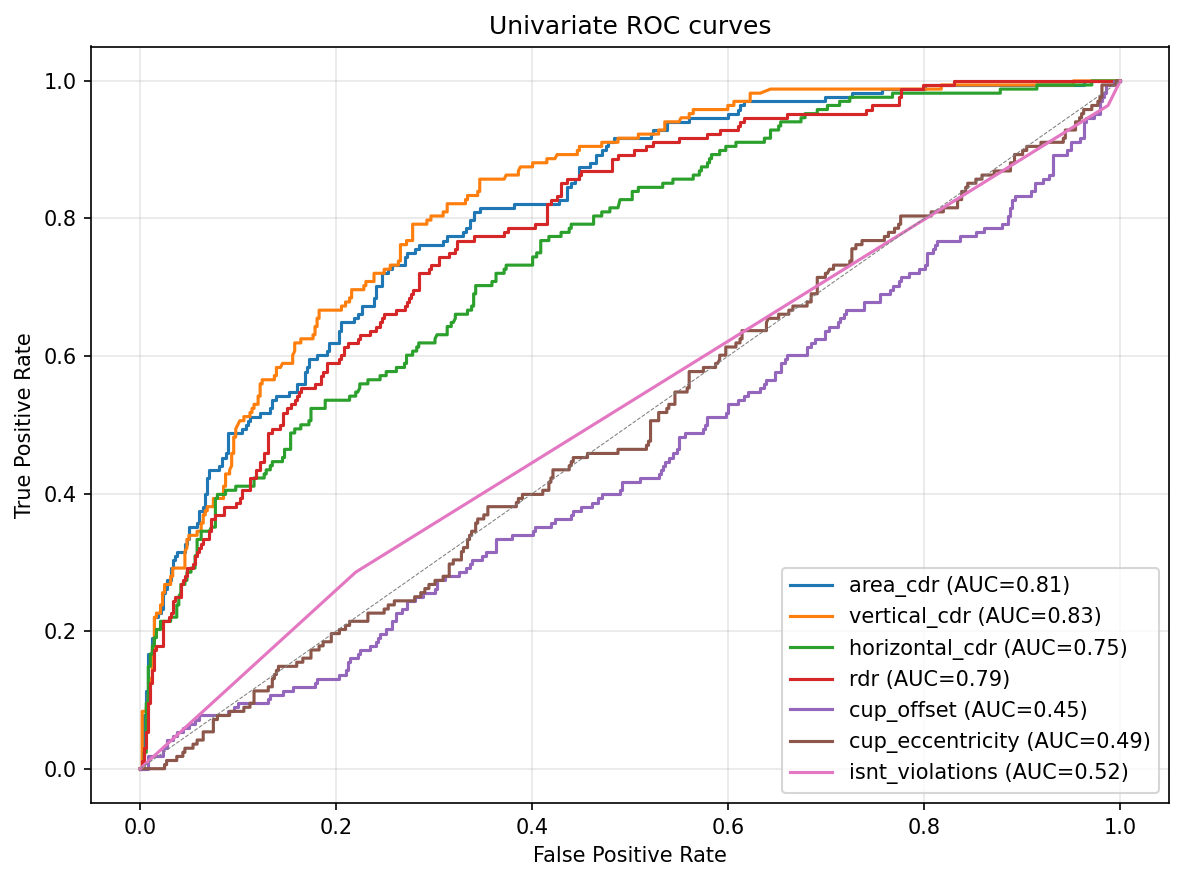

In [15]:
df_stats = pd.DataFrame(r["univariate"]).set_index("metric")
display(df_stats[["auc", "mw_p", "ks_p", "t_p", "f"]].round(4))
display(Image(filename=str(RESULTS_DIR / "univariate_roc.png")))

### Conclusion

Although several geometric markers exhibit statistically significant differences between healthy and glaucomatous eyes (Mann–Whitney U, KS, and Welch’s t-tests), the observed effect sizes indicate substantial overlap between class distributions. This confirms that statistical significance alone does not imply strong discriminative power.

The ROC analysis confirms that vertical CDR provides the strongest univariate discrimination, while other markers such as rim-to-disc ratio perform less effectively on ORIGA than reported in prior literature. Importantly, all ROC curves exhibit gradual slopes rather than sharp transitions, highlighting that no single geometric marker can perfectly separate healthy and glaucomatous eyes. 

## 4. Multivariate modelling (cross-validated AUC)

In [16]:
model_df = pd.DataFrame({
    "CV-AUC (5-fold)": {
        "Random Forest":            f'{r["cv_auc"]["random_forest"]:.4f}',
        "Logistic Regression (L1)": f'{r["cv_auc"]["logistic_regression"]:.4f}',
    }
})
display(model_df)

,CV-AUC (5-fold)
Random Forest,0.7935
Logistic Regression (L1),0.8244


In [17]:
lr_coefs = pd.Series(r["lr_coefficients"], name="LR coefficient").sort_values(ascending=False)
rf_imp   = pd.Series(r["rf_importances"],  name="RF importance").sort_values(ascending=False)

print("Logistic Regression - non-zero L1 coefficients:")
display(lr_coefs.to_frame())
print("\nRandom Forest - retained feature importances:")
display(rf_imp.to_frame())

Logistic Regression - non-zero L1 coefficients:


,LR coefficient
vertical_cdr,1.3694
isnt_violations,0.1594
rdr,0.1184
cup_offset,0.0044
cup_eccentricity,-0.0875



Random Forest - retained feature importances:


,RF importance
vertical_cdr,0.318123
area_cdr,0.279913
rdr,0.213503
horizontal_cdr,0.188462


### Conclusion

Despite combining multiple geometric markers, both the logistic regression and random forest models fail to outperform the best univariate metric (vertical CDR). This suggests that much of the discriminative information is shared between features, and that multivariate models primarily repackage existing information rather than uncovering new separability.